## R-Star testing with the inclusion of oscillation parameters

The `xsec_` parameters are known as the 'nuisance paramters' since they are there because they have to be there; what is more interesting are the oscillation params which tell us about the PMNS matrix and ulitmately CP violation. We are essentially limit testing R* on data that looks wierd. 

The distribution of delta_m232 is 2 gaussians, one on the rhs of the y axis (referred to as the normal ordering) and one on the left (referred to as reverse ordering); we want to know how R* handles this and compare it R-Hat since the R-Hat diagnostic is based on between chain and within chain variances. This will be an effective comparison between the two diagnostics.

This notebook runs similar code to `basic_sklearn.ipynb` but with the inclusion of oscillation parameters. 

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown
import arviz as az

Using mps device

## How does R* behave when 2 identical chain files slowly become more random with the inclusion of oscillation paramters.
> At what value of R* can we say with confidence that the ML Classifier distinguishes between the 2 chains as good as random guessing.

The code below is similar to the code in `basic_sklearn.ipynb` with the addition of the oscillation params.


In [7]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/all_on_ADT2K/identical/")
path_to_1= Path("../models/demo_files 2/all_on_ADT2K/level 1/")
path_to_2= Path("../models/demo_files 2/all_on_ADT2K/level 2/")
path_to_3= Path("../models/demo_files 2/all_on_ADT2K/level 3/")
path_to_4= Path("../models/demo_files 2/all_on_ADT2K/level 4/")
path_to_5= Path("../models/demo_files 2/all_on_ADT2K/level 5/")
path_to_6= Path("../models/demo_files 2/all_on_ADT2K/level 6/")
path_to_7= Path("../models/demo_files 2/all_on_ADT2K/level 7/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]

fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(['baseline', 'density', 'Ye', "xsec_19", "xsec_20",])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18",  "xsec_21", "xsec_22"])
        chain_handler.add_additional_plots(['sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"]) #>0 chooses the normal ordering; <0 chooses reverse ordering; removing the cut chooses both
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data2= temp_identical[1]

level1_data = temp1[0]
level1_data2= temp1[1]

'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level1_data2.ttree_array[f'xsec_{m}']= level1_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'xsec_{m}']))*0.00000001)

level1_data2.ttree_array[f'sin2th_12']= level1_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_12']))*0.00000001)
level1_data2.ttree_array[f'sin2th_23']=level1_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_23']))*0.00000001)
level1_data2.ttree_array[f'sin2th_13']=level1_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'sin2th_13']))*0.00000001)
level1_data2.ttree_array[f'delm2_12']=level1_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_12']))*0.00000001)
level1_data2.ttree_array[f'delm2_23']=level1_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delm2_23']))*0.00000001)
'''
level1_data2.ttree_array[f'delta_cp']=level1_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level1_data2.ttree_array[f'delta_cp']))*0.00000001)


level2_data = temp2[0]
level2_data2= temp2[1]

'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level2_data2.ttree_array[f'xsec_{m}']= level2_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'xsec_{m}']))*0.0000001)

level2_data2.ttree_array[f'sin2th_12']= level2_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_12']))*0.0000001)
level2_data2.ttree_array[f'sin2th_23']=level2_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_23']))*0.0000001)
level2_data2.ttree_array[f'sin2th_13']=level2_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'sin2th_13']))*0.0000001)
level2_data2.ttree_array[f'delm2_12']=level2_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_12']))*0.0000001)
level2_data2.ttree_array[f'delm2_23']=level2_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delm2_23']))*0.0000001)
'''
level2_data2.ttree_array[f'delta_cp']=level2_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level2_data2.ttree_array[f'delta_cp']))*0.0000001)


level3_data = temp3[0]
level3_data2= temp3[1]

'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level3_data2.ttree_array[f'xsec_{m}']= level3_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'xsec_{m}']))*0.000001)

level3_data2.ttree_array[f'sin2th_12']= level3_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_12']))*0.000001)
level3_data2.ttree_array[f'sin2th_23']=level3_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_23']))*0.000001)
level3_data2.ttree_array[f'sin2th_13']=level3_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'sin2th_13']))*0.000001)
level3_data2.ttree_array[f'delm2_12']=level3_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_12']))*0.000001)
level3_data2.ttree_array[f'delm2_23']=level3_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delm2_23']))*0.000001)
'''
level3_data2.ttree_array[f'delta_cp']=level3_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level3_data2.ttree_array[f'delta_cp']))*0.000001)


level4_data = temp4[0]
level4_data2= temp4[1]


'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level4_data2.ttree_array[f'xsec_{m}']= level4_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'xsec_{m}']))*0.00001)

level4_data2.ttree_array[f'sin2th_12']= level4_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_12']))*0.00001)
level4_data2.ttree_array[f'sin2th_23']=level4_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_23']))*0.00001)
level4_data2.ttree_array[f'sin2th_13']=level4_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'sin2th_13']))*0.00001)
level4_data2.ttree_array[f'delm2_12']=level4_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_12']))*0.00001)
level4_data2.ttree_array[f'delm2_23']=level4_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delm2_23']))*0.00001)
'''
level4_data2.ttree_array[f'delta_cp']=level4_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level4_data2.ttree_array[f'delta_cp']))*0.00001)



level5_data = temp5[0]
level5_data2= temp5[1]


'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level5_data2.ttree_array[f'xsec_{m}']= level5_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'xsec_{m}']))*0.0001)

level5_data2.ttree_array[f'sin2th_12']= level5_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_12']))*0.0001)
level5_data2.ttree_array[f'sin2th_23']=level5_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_23']))*0.0001)
level5_data2.ttree_array[f'sin2th_13']=level5_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'sin2th_13']))*0.0001)
level5_data2.ttree_array[f'delm2_12']=level5_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_12']))*0.0001)
level5_data2.ttree_array[f'delm2_23']=level5_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delm2_23']))*0.0001)
'''
level5_data2.ttree_array[f'delta_cp']=level5_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level5_data2.ttree_array[f'delta_cp']))*0.0001)



level6_data = temp6[0]
level6_data2= temp6[1]

'''
for m in range(23):
    if m == 19:
        continue  
    elif m == 20:
        continue
    level6_data2.ttree_array[f'xsec_{m}']= level6_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'xsec_{m}'])))

level6_data2.ttree_array[f'sin2th_12']= level6_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_12'])))
level6_data2.ttree_array[f'sin2th_23']=level6_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_23'])))
level6_data2.ttree_array[f'sin2th_13']=level6_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'sin2th_13'])))
level6_data2.ttree_array[f'delm2_12']=level6_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_12'])))
level6_data2.ttree_array[f'delm2_23']=level6_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delm2_23'])))
'''
level6_data2.ttree_array[f'delta_cp']=level6_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level6_data2.ttree_array[f'delta_cp'])))


level7_data = temp7[0]
level7_data2= temp7[1]


'''
for m in range(23):
    if m == 19:
        continue
    elif m == 20:
        continue
    level7_data2.ttree_array[f'xsec_{m}']= level7_data2.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'xsec_{m}']))*10)

level7_data2.ttree_array[f'sin2th_12']= level7_data2.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_12']))*10)
level7_data2.ttree_array[f'sin2th_23']=level7_data2.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_23']))*10)
level7_data2.ttree_array[f'sin2th_13']=level7_data2.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'sin2th_13']))*10)
level7_data2.ttree_array[f'delm2_12']=level7_data2.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_12']))*10)
level7_data2.ttree_array[f'delm2_23']=level7_data2.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delm2_23']))*10)
'''
level7_data2.ttree_array[f'delta_cp']=level7_data2.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(level7_data2.ttree_array[f'delta_cp']))*10)
# Convert the pandas DataFrame for each chain to a numpy array.
# This is necessary because ArviZ expects numpy arrays or xarray objects, not DataFrames.

res=[] #converts the DatFrames into numpy arrays, appends them to a list (res)
a= [identical_data, identical_data2, level1_data, level1_data2, level2_data, level2_data2, level3_data, level3_data2, level4_data, level4_data2, level5_data, level5_data2, level6_data, level6_data2, level7_data, level7_data2]
for n in a:
    new= n.ttree_array.values
    res.append(new)

#array1 = identical_data.ttree_array.values  # shape is shape (n_draws, n_params)
#array2 = identical_data2.ttree_array.values  


#chains = np.stack([array1, array2]) # shape: (n_chains, n_draws, n_params); now need to extract a specific parameter and map to which chain it came from (n_chain) 
                                # and how many draws it has - the length of the coloumn (n_draws), since ArviZ allows you to pass (n_chain, n_draws) per parameter
chains_id= np.stack([res[0], res[1]])
chains_1= np.stack([res[2], res[3]])
chains_2= np.stack([res[4], res[5]])
chains_3= np.stack([res[6], res[7]])
chains_4= np.stack([res[8], res[9]])
chains_5= np.stack([res[10], res[11]])
chains_6= np.stack([res[12], res[13]])
chains_7= np.stack([res[14], res[15]])


param_names = identical_data2.ttree_array.columns.tolist()

# Build a dictionary (using dictionary comperehension: posterior= ... ) # where each parameter name maps to a (n_chains, n_draws) array.
                                                                                           
data_id = az.from_dict(posterior={name: chains_id[:,:,i] for i, name in enumerate(param_names)})# chains[:,:,i] selects all chains and draws for the i-th parameter.
                                                                                          # chains[:,:,i]== chains(n_chains, n_draws, n_params)
                                                                                           
data_1 = az.from_dict(posterior={name: chains_1[:,:,i] for i, name in enumerate(param_names)})
data_2 = az.from_dict(posterior={name: chains_2[:,:,i] for i, name in enumerate(param_names)})
data_3 = az.from_dict(posterior={name: chains_3[:,:,i] for i, name in enumerate(param_names)})
data_4 = az.from_dict(posterior={name: chains_4[:,:,i] for i, name in enumerate(param_names)})
data_5= az.from_dict(posterior={name: chains_5[:,:,i] for i, name in enumerate(param_names)})
data_6 = az.from_dict(posterior={name: chains_6[:,:,i] for i, name in enumerate(param_names)})
data_7 = az.from_dict(posterior={name: chains_7[:,:,i] for i, name in enumerate(param_names)})


rhat_id= az.rhat(data_id)
rhat1=az.rhat(data_1)
rhat2=az.rhat(data_2)
rhat3=az.rhat(data_3)
rhat4=az.rhat(data_4)
rhat5=az.rhat(data_5)
rhat6=az.rhat(data_6)
rhat7= az.rhat(data_7)


print(rhat_id["delta_cp"])

['../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/identical/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 1/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 2/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 3/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 4/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on_copy.root', '../models/demo_files 2/all_on_ADT2K/level 5/mcmc_Adapt_T2K_all_on.root']
['../models/demo_files 2/all_on_ADT2K/level 6/mcmc_Adapt_T2K_all_on_copy

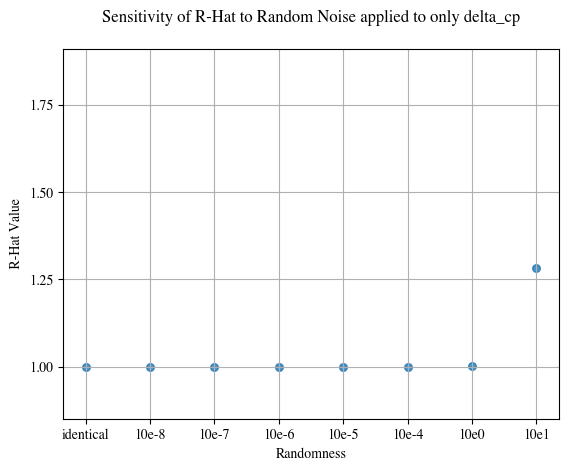

In [65]:

x = [2, 3, 4, 5, 6, 7, 8, 9]
y= [rhat_id['delta_cp'], rhat1['delta_cp'], rhat2['delta_cp'], rhat3['delta_cp'], rhat4['delta_cp'], rhat5['delta_cp'], rhat6['delta_cp'], rhat7['delta_cp'] ] 
ymin, ymax = min(y), max(y)
pad =0.5 #(ymax - ymin) * 0.3
plt.ylim(ymin-0.15, ymax + 0.625)
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], ['identical','10e-8', '10e-7', '10e-6', '10e-5', '10e-4', '10e0', '10e1'])
plt.yticks([1.00, 1.25, 1.50, 1.75], ['1.00','1.25', '1.50', '1.75'])

plt.scatter(x, y, alpha=0.8, s=30)


plt.rcParams["font.family"] = "Times"

#plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   

plt.title('Sensitivity of R-Hat to Random Noise applied to only delta_cp', pad=20)
plt.xlabel('Randomness')
plt.ylabel(' R-Hat Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()

